#**HPDP Assignment 2: Mastering Big Data Handling**

**Student Info:**\
**1. Chua Jia Lin A23CS0069**\
**2. Joanne Ching Yin Xuan A23CS0227**

 ## **Task 1: Dataset Selection**

**1. Setup and Introduction**
* **Purpose:** To implement and compare strategies for handling large datasets.
* **Libraries:** Import all necessary Python libraries.


In [ ]:
import pandas as pd
import numpy as np
import csv
import time
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt

**2. Dataset Details**
* **Source:** [Transactions Dataset on Kaggle](https://www.kaggle.com/datasets/ismetsemedov/transactions/data)
* **Size:** 2.73GB
* **Records:** 7,483,766 rows
* **Domain:** Finance

## **Task 2: Load and Inspect Data**

**3. Load and Inspect Data**
* Load the dataset.
* Display the following:
  - First few rows (head())
  - Shape of the dataset
  - Column names
  - Data types of each column

**Step 1:** Import kaggle.json

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chuajl","key":"7db518007e794330421aeaa6201fdb32"}'}

**Step 2:** Move it to the correct location

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

**Step 3:** Download Dataset from Kaggle

In [ ]:
!kaggle datasets download -d ismetsemedov/transactions

Dataset URL: https://www.kaggle.com/datasets/ismetsemedov/transactions
License(s): apache-2.0
100% 754M/754M [00:31<00:00, 25.2MB/s]



**Step 4:** Unzip the file

In [ ]:
!unzip transactions.zip

Archive:  transactions.zip
  inflating: synthetic_fraud_data.csv  


**Step 5:** Read the csv and display rows, shape, column and data types of each column, and number of NULL records  of each column of the dataset

In [ ]:
df = pd.read_csv('synthetic_fraud_data.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn Names and Data Types:\n", df.dtypes)

print("\nNumber of NULL records in each column:\n", df.isnull().sum())


First 5 rows of the dataset:


,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True



Dataset shape: (7483766, 24)

Column Names and Data Types:
 transaction_id          object
customer_id             object
card_number              int64
timestamp               object
merchant_category       object
merchant_type           object
merchant                object
amount                 float64
currency                object
country                 object
city                    object
city_size               object
card_type               object
card_present              bool
device                  object
channel                 object
device_fingerprint      object
ip_address              object
distance_from_home       int64
high_risk_merchant        bool
transaction_hour         int64
weekend_transaction       bool
velocity_last_hour      object
is_fraud                  bool
dtype: object

Number of NULL records in each column:
 transaction_id         0
customer_id            0
card_number            0
timestamp              0
merchant_category      0
merchant_type  

## **Task 3: Big Data Handling Strategies**

**Apply Big Data Handling Strategies**\
In this notebook, five effective strategies are applied to handle large datasets. Part 1 focuses on implementing optimisation techniques using Pandas, while Part 2 compares the performance of three libraries: Pandas, Dask, and Polars.

Part 1 uses a subset of 1 million records to reduce memory usage and speed up development. This allows efficient testing and demonstration of each strategy without overloading the system.

Part 2 uses the full dataset for each library to ensure a fair and realistic performance comparison. Evaluating all libraries on the same complete dataset provides accurate measurements of execution time and memory usage, and better reflects real-world data processing scenarios.

---

**Part 1:**
- Load Less Data  
- Use Chunking  
- Optimise Data Types  
- Sampling  
- Parallel Processing with Scalable Libraries (Polars & Dask)  

**Part 2:**
- Pandas  
- Dask  
- Polars  

**Part 1**\
**Strategy 1: Load Less Data**\
In this step, we reduced the memory footprint by loading only 7 relevant columns instead of the full 24-column dataset. This helps optimize performance during initial data exploration or modeling phases where not all data is needed.


In [ ]:
# Select only the necessary columns to reduce memory usage
selected_cols = ['transaction_id', 'customer_id', 'merchant', 'amount', 'currency', 'high_risk_merchant', 'is_fraud']

# Measure execution time
start_time = time.time()

# Load only the selected columns
df_selected = pd.read_csv('synthetic_fraud_data.csv', usecols=selected_cols, nrows=1000000)

# Execution time
exec_time = time.time() - start_time

# Display basic info
print("Dataset shape:", df_selected.shape)
print("First 5 records:\n", df_selected.head())

# Memory used
mem_used = df_selected.memory_usage(deep=True).sum() / (1024**2)  # in MiB
print("\nMemory usage:", round(mem_used, 2), "MiB")
print("Execution time:", round(exec_time, 2),  "seconds")

Dataset shape: (1000000, 7)
First 5 records:
   transaction_id customer_id        merchant     amount currency  \
0    TX_a0ad2a2a  CUST_72886       Taco Bell     294.87      GBP   
1    TX_3599c101  CUST_70474           Steam    3368.97      BRL   
2    TX_a9461c6d  CUST_10715     Whole Foods  102582.38      JPY   
3    TX_7be21fc4  CUST_16193           Exxon     630.60      AUD   
4    TX_150f490b  CUST_87572  Medical Center  724949.27      NGN   

   high_risk_merchant  is_fraud  
0               False     False  
1                True      True  
2               False     False  
3               False     False  
4               False      True  

Memory usage: 228.28 MiB
Execution time: 6.05 seconds


**Strategy 2: Use Chunking**\
Chunking allows us to read large files without overloading memory. By setting a chunksize, we create an iterator that reads the file in parts. This is especially useful for preprocessing, aggregation, or transformation steps before full dataset loading.

In [ ]:
chunksize = 200000
chunk_iter = pd.read_csv("synthetic_fraud_data.csv", chunksize=chunksize, nrows=1000000)

total_rows = 0
max_mem = 0

# Measure execution time
start_time = time.time()

# Process chunks
for i, chunk in enumerate(chunk_iter):
    print("Chunk", i+1, ":", chunk.shape)
    print("First 5 rows of Chunk", i+1, ":\n", chunk.head())
    print("-" * 50)
    total_rows += len(chunk)
    mem_used = chunk.memory_usage(deep=True).sum() / (1024 ** 2)
    max_mem = max(max_mem, mem_used)

print("Finished processing all chunks!")

# Execution time
exec_time = time.time() - start_time

# Display basic info
print("Total rows processed:", total_rows)
print("\nMaximum memory used:", round(max_mem, 2), "MiB")
print("Total execution time:", round(exec_time, 2), "seconds")


Chunk 1 : (200000, 24)
First 5 rows of Chunk 1 :
   transaction_id customer_id       card_number  \
0    TX_a0ad2a2a  CUST_72886  6646734767813109   
1    TX_3599c101  CUST_70474   376800864692727   
2    TX_a9461c6d  CUST_10715  5251909460951913   
3    TX_7be21fc4  CUST_16193   376079286931183   
4    TX_150f490b  CUST_87572  6172948052178810   

                          timestamp merchant_category merchant_type  \
0  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food   
1  2024-09-30 00:00:01.764464+00:00     Entertainment        gaming   
2  2024-09-30 00:00:02.273762+00:00           Grocery      physical   
3  2024-09-30 00:00:02.297466+00:00               Gas         major   
4  2024-09-30 00:00:02.544063+00:00        Healthcare       medical   

         merchant     amount currency    country  ...   device channel  \
0       Taco Bell     294.87      GBP         UK  ...  iOS App  mobile   
1           Steam    3368.97      BRL     Brazil  ...     Edge     web   


**Strategy 3: Optimize Data Types**\
By converting high-cardinality string columns such as transaction_id and merchant to category, and numeric columns such as amount and transaction_hour to smaller data types, we significantly reduce memory usage. This is vital when scaling data operations or loading multiple files.


In [ ]:
# Start timing
start_time = time.time()

# Load the dataset
df = pd.read_csv("synthetic_fraud_data.csv", nrows=1000000)

# Optimize data types during loading
df["transaction_id"] = df["transaction_id"].astype("category")
df["customer_id"] = df["customer_id"].astype("category")
df["card_number"] = df["card_number"].astype("string")
df["merchant_category"] = df["merchant_category"].astype("category")
df["merchant_type"] = df["merchant_type"].astype("category")
df["merchant"] = df["merchant"].astype("category")
df["amount"] = df["amount"].astype("float32")
df["currency"] = df["currency"].astype("category")
df["country"] = df["country"].astype("category")
df["city"] = df["city"].astype("category")
df["city_size"] = df["city_size"].astype("category")
df["card_type"] = df["card_type"].astype("category")
df["device"] = df["device"].astype("category")
df["channel"] = df["channel"].astype("category")
df["distance_from_home"] = df["distance_from_home"].astype("int16")
df["transaction_hour"] = df["transaction_hour"].astype("int8")

# Execution time
exec_time = time.time() - start_time

# Measure memory usage
mem_used = df.memory_usage(deep=True).sum() / (1024**2)

# Output
print("\nMemory usage:", round(mem_used, 2), "MiB")
print("Execution time:", round(exec_time, 2),  "seconds")
print("\nColumn Names and Data Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head(5))


Memory usage: 580.79 MiB
Execution time: 17.8 seconds

Column Names and Data Types:
 transaction_id               category
customer_id                  category
card_number            string[python]
timestamp                      object
merchant_category            category
merchant_type                category
merchant                     category
amount                        float32
currency                     category
country                      category
city                         category
city_size                    category
card_type                    category
card_present                     bool
device                       category
channel                      category
device_fingerprint             object
ip_address                     object
distance_from_home              int16
high_risk_merchant               bool
transaction_hour                 int8
weekend_transaction              bool
velocity_last_hour             object
is_fraud                         bool
dt


**Strategy 4: Sampling**\
Sampling uses a small, representative slice of a dataset to validate code and logic rapidly, saving time and compute costs before running the full-scale process.

In [ ]:
# Measure execution time
start_time = time.time()

# Load dataset (limited rows for fair comparison)
df_full = pd.read_csv("synthetic_fraud_data.csv", nrows=1000000)

# Apply sampling
df_sample = df_full.sample(frac=0.1, random_state=42)

# Execution time
sampling_time = time.time() - start_time

# Memory usage
mem_sampling = df_sample.memory_usage(deep=True).sum() / (1024**2)

# Output
print("Original rows:", df_full.shape[0])
print("Sampled rows:", df_sample.shape[0])
print("Memory usage (sample):", round(mem_sampling, 2), "MiB")
print("Execution time: ", round(sampling_time, 2), "seconds")

# Preview
df_sample.head()

Original rows: 1000000
Sampled rows: 100000
Memory usage (sample): 109.74 MiB
Execution time:  11.27 seconds


,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
987231,TX_10590843,CUST_29883,6610483208684354,2024-10-04 02:43:20.137067+00:00,Retail,online,Wayfair,1525.96,SGD,Singapore,...,Safari,web,c17c495ab74c6b8b4266464cf473b07e,32.163.1.148,1,False,2,False,"{'num_transactions': 45, 'total_amount': 92971...",False
79954,TX_b1d27d3c,CUST_34590,6628200809420891,2024-09-30 09:17:10.027847+00:00,Travel,airlines,Emirates,303.10,AUD,Australia,...,Edge,web,44600ebdf967eb82d7f19958a60bb879,18.149.104.132,1,True,9,False,"{'num_transactions': 1478, 'total_amount': 622...",False
567130,TX_754f5471,CUST_59622,6495194807928585,2024-10-02 09:35:24.280550+00:00,Grocery,physical,Publix,179249.07,NGN,Nigeria,...,Safari,web,ffb25cfa98debeca70f9d4daf9c8c054,65.126.255.229,0,False,9,False,"{'num_transactions': 990, 'total_amount': 1692...",False
500891,TX_79d1dcac,CUST_34628,5650929729288227,2024-10-02 02:26:05.627667+00:00,Grocery,physical,Whole Foods,98.98,RUB,Russia,...,NFC Payment,pos,e7443245452dd3130ea6cfe78a2e29e6,71.67.139.75,1,False,2,False,"{'num_transactions': 1106, 'total_amount': 155...",True
55399,TX_f99cd54c,CUST_51171,5971021546492943,2024-09-30 07:09:09.746193+00:00,Education,online,Coursera,316.93,EUR,Germany,...,Edge,web,8dc18f9d0049222a3f18432a2dae8386,50.28.229.74,0,False,7,False,"{'num_transactions': 1587, 'total_amount': 432...",False


**Strategy 5: Parallel Processing with Scalable Libraries**

This section demonstrates how parallel processing improves performance when handling large datasets by executing operations simultaneously using multiple CPU cores instead of sequential processing.

- **Library Used**  
  - Polars
  - Dask
-------------------



  
  **- Library Used: Polars**  
  Polars is used as it supports multi-threaded execution by default. Unlike Pandas, which is single-threaded, Polars distributes operations across multiple CPU cores, resulting in faster and more efficient data processing.

**- Implementation**  
  The code performs:
  - Loads the dataset using dask.dataframe.read_csv()
  - Triggers computation using .compute() to execute the delayed operations
  - Filtering transaction amounts greater than 100  
  - Grouping data by merchant category  
  - Calculating aggregate statistics (average and count)
  - Calculates memory usage using .estimated_size() in MiB
  - Displays a sample of the processed dataset using head()

**- Result**  
  Polars demonstrates efficient parallel processing through its multi-threaded execution engine, resulting in faster execution times and optimized performance for data transformation tasks. However, memory usage may increase depending on the complexity of operations, as intermediate computations are stored in memory during processing.

In [ ]:
import polars as pl
import time

print("\n--- Parallel Processing using Polars ---")

# Start timing
start_time = time.time()

# Load dataset (multi-threaded internally)
df = pl.read_csv("synthetic_fraud_data.csv", n_rows=1_000_000)

# Measure memory usage (in MiB)
mem_before = df.estimated_size("mb")

# Parallel operations
result = (
    df
    .filter(pl.col("amount") > 100)
    .group_by("merchant_category")
    .agg([
        pl.col("amount").mean().alias("avg_amount"),
        pl.col("amount").count().alias("transaction_count")
    ])
)

# Measure result memory
mem_after = result.estimated_size("mb")

# End timing
end_time = time.time()

# Output
print(result.head())
print("\nExecution Time:", round(end_time - start_time, 2), "seconds")
print("Memory Usage (Before):", round(mem_before, 2), "MiB")


--- Parallel Processing using Polars ---
shape: (5, 3)
┌───────────────────┬──────────────┬───────────────────┐
│ merchant_category ┆ avg_amount   ┆ transaction_count │
│ ---               ┆ ---          ┆ ---               │
│ str               ┆ f64          ┆ u32               │
╞═══════════════════╪══════════════╪═══════════════════╡
│ Education         ┆ 48041.032007 ┆ 118790            │
│ Retail            ┆ 65623.423271 ┆ 119067            │
│ Restaurant        ┆ 30708.818139 ┆ 107907            │
│ Entertainment     ┆ 32767.580373 ┆ 111443            │
│ Gas               ┆ 49028.253544 ┆ 119424            │
└───────────────────┴──────────────┴───────────────────┘

Execution Time: 12.08 seconds
Memory Usage (Before): 338.77 MiB


**- Library Used: Dask**  
  Dask is used as a parallel computing library that enables scalable data processing through lazy evaluation and task-based execution. Unlike Pandas, which loads and processes data in memory sequentially, Dask splits operations into parallel tasks and computes them efficiently when .compute() is called.

**- Implementation**  
  The code performs:
  - Loads the dataset using dask.dataframe.read_csv()
  - Triggers computation using .compute() to execute the delayed operations
  - Measures total execution time for loading and computation
  - Calculates memory usage in MiB
  - Displays a sample of the processed dataset using head()

**- Result**  
  Dask provides improved scalability for larger datasets by enabling parallel execution and out-of-core processing.


In [ ]:
import dask.dataframe as dd
import time

# Start timing
start_time = time.time()

# Load data using Dask
df = dd.read_csv("synthetic_fraud_data.csv")

# Trigger computation
df = df.compute()

# End timing
end_time = time.time()

# Memory usage in MiB
mem_used = df.memory_usage(deep=True).sum() / (1024**2)

print(df.head())
print("Execution time:", round(end_time - start_time, 2), "seconds")
print("Memory usage:", round(mem_used, 2), "MiB")

  transaction_id customer_id       card_number  \
0    TX_a0ad2a2a  CUST_72886  6646734767813109   
1    TX_3599c101  CUST_70474   376800864692727   
2    TX_a9461c6d  CUST_10715  5251909460951913   
3    TX_7be21fc4  CUST_16193   376079286931183   
4    TX_150f490b  CUST_87572  6172948052178810   

                          timestamp merchant_category merchant_type  \
0  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food   
1  2024-09-30 00:00:01.764464+00:00     Entertainment        gaming   
2  2024-09-30 00:00:02.273762+00:00           Grocery      physical   
3  2024-09-30 00:00:02.297466+00:00               Gas         major   
4  2024-09-30 00:00:02.544063+00:00        Healthcare       medical   

         merchant     amount currency    country  ...   device channel  \
0       Taco Bell     294.87      GBP         UK  ...  iOS App  mobile   
1           Steam    3368.97      BRL     Brazil  ...     Edge     web   
2     Whole Foods  102582.38      JPY      Japan  

**Part 2**\
**1. Full Load with Pandas**

In [ ]:
start = time.time()

# Load complete dataset
df_pandas = pd.read_csv("synthetic_fraud_data.csv")

end = time.time()

# Calculate memory
mem_pandas = df_pandas.memory_usage(deep=True).sum() / (1024**2)

# Show basic info
print(df_pandas.head(5))
print("Shape:", df_pandas.shape)
print(f"Execution Time: {end - start:.2f} seconds")
print(f"Memory usage: {mem_pandas:.2f} MiB")

  transaction_id customer_id       card_number  \
0    TX_a0ad2a2a  CUST_72886  6646734767813109   
1    TX_3599c101  CUST_70474   376800864692727   
2    TX_a9461c6d  CUST_10715  5251909460951913   
3    TX_7be21fc4  CUST_16193   376079286931183   
4    TX_150f490b  CUST_87572  6172948052178810   

                          timestamp merchant_category merchant_type  \
0  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food   
1  2024-09-30 00:00:01.764464+00:00     Entertainment        gaming   
2  2024-09-30 00:00:02.273762+00:00           Grocery      physical   
3  2024-09-30 00:00:02.297466+00:00               Gas         major   
4  2024-09-30 00:00:02.544063+00:00        Healthcare       medical   

         merchant     amount currency    country  ...   device channel  \
0       Taco Bell     294.87      GBP         UK  ...  iOS App  mobile   
1           Steam    3368.97      BRL     Brazil  ...     Edge     web   
2     Whole Foods  102582.38      JPY      Japan  

**2. Full Load with Dask**

In [ ]:
start = time.time()

# Load dataset lazily
ddf = dd.read_csv("synthetic_fraud_data.csv")

# Force full load into memory
df_dask = ddf.compute()

end = time.time()

# Calculate memory
mem_dask = df_dask.memory_usage(deep=True).sum() / (1024**2)

# Show basic info
print(df_dask.head(5))
print("Shape:", df_dask.shape)
print(f"Execution Time: {end - start:.2f} seconds")
print(f"Memory usage: {mem_dask:.2f} MiB")

# Dask loads data lazily, but .compute() forces full dataset into memory.

  transaction_id customer_id       card_number  \
0    TX_a0ad2a2a  CUST_72886  6646734767813109   
1    TX_3599c101  CUST_70474   376800864692727   
2    TX_a9461c6d  CUST_10715  5251909460951913   
3    TX_7be21fc4  CUST_16193   376079286931183   
4    TX_150f490b  CUST_87572  6172948052178810   

                          timestamp merchant_category merchant_type  \
0  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food   
1  2024-09-30 00:00:01.764464+00:00     Entertainment        gaming   
2  2024-09-30 00:00:02.273762+00:00           Grocery      physical   
3  2024-09-30 00:00:02.297466+00:00               Gas         major   
4  2024-09-30 00:00:02.544063+00:00        Healthcare       medical   

         merchant     amount currency    country  ...   device channel  \
0       Taco Bell     294.87      GBP         UK  ...  iOS App  mobile   
1           Steam    3368.97      BRL     Brazil  ...     Edge     web   
2     Whole Foods  102582.38      JPY      Japan  

**3. Full Load with Polars**

In [ ]:
# Measure execution time
start_time = time.time()

# Load complete dataset
df_polars = pl.read_csv("synthetic_fraud_data.csv")

# Execution time
exec_time = time.time() - start_time

# Measure memory usage
mem_used = df_polars.estimated_size() / (1024**2)

# Show basic info
print("First 5 rows:", df_polars.head(5))
print("Shape:", df_polars.shape)
print("Execution Time:", round(exec_time, 2), "seconds")
print("Memory usage:", round(mem_used, 2), "MiB")

First 5 rows: shape: (5, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ transacti ┆ customer_ ┆ card_numb ┆ timestamp ┆ … ┆ transacti ┆ weekend_t ┆ velocity_ ┆ is_fraud │
│ on_id     ┆ id        ┆ er        ┆ ---       ┆   ┆ on_hour   ┆ ransactio ┆ last_hour ┆ ---      │
│ ---       ┆ ---       ┆ ---       ┆ str       ┆   ┆ ---       ┆ n         ┆ ---       ┆ bool     │
│ str       ┆ str       ┆ i64       ┆           ┆   ┆ i64       ┆ ---       ┆ str       ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆ bool      ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ TX_a0ad2a ┆ CUST_7288 ┆ 664673476 ┆ 2024-09-3 ┆ … ┆ 0         ┆ false     ┆ {'num_tra ┆ false    │
│ 2a        ┆ 6         ┆ 7813109   ┆ 0 00:00:0 ┆   ┆           ┆           ┆ nsactions ┆          │
│           ┆           ┆           ┆ 1.034820+ ┆   ┆         

## **Task 5: Comparative Analysis**




**1. Compare between Big Data Handling Strategies**
* Load Less Data
* Use Chunking
* Optimize Data Types
* Sampling
* Parallel Processing with Polars
* Parallel Processing with Dask


Two bar charts are generated:
* One compares the execution time (in seconds).
* The other compares the memory usage (in MB).

This analysis helps to identify which strategy offers the best trade-off between speed and memory efficiency when using traditional vs. parallelized approaches.

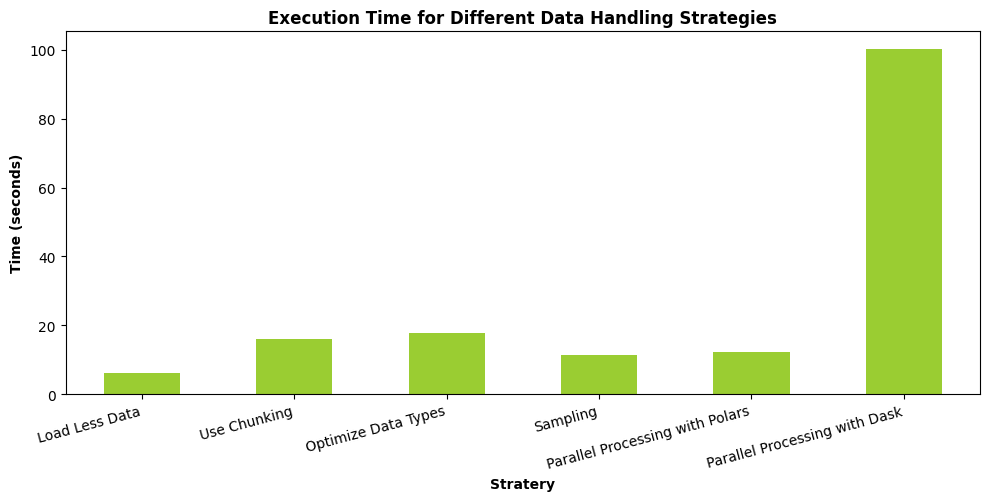

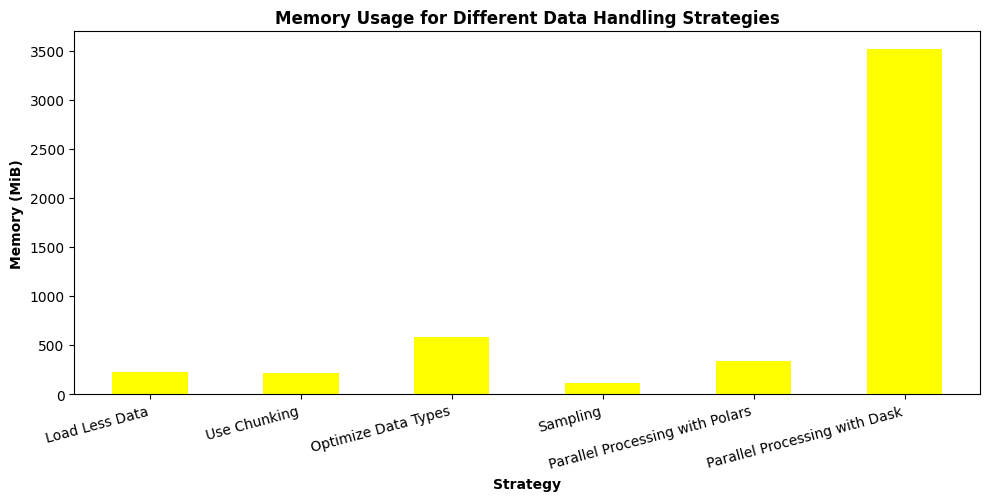

In [ ]:
import matplotlib.pyplot as plt

# Define comparison data
strategies = [
    "Load Less Data",
    "Use Chunking",
    "Optimize Data Types",
    "Sampling",
    "Parallel Processing with Polars",
    "Parallel Processing with Dask"
]

execution_time = [
    6.05,   # Pandas: Load Less Data
    15.97,   # Pandas: Use Chunking
    17.8,   # Pandas: Optimize Data Types
    11.27,    # Pandas: Sampling
    12.08,    # Polars: Parallel Processing
    100.4  # Dask: Parallel Processing
]

memory_usage = [
    228.28,  # Pandas: Load Less Data
    217.97,  # Pandas: Use Chunking
    580.79,  # Pandas: Optimize Data Types
    109.74,  # Pandas: Sampling
    338.77,   # Polars: Parallel Processing
    3523.78  # Dask: Parallel Processing
]

# Create DataFrames
df_comparison = pd.DataFrame({
    "Strategy": strategies,
    "Execution Time (s)": execution_time,
    "Memory Usage (MiB)": memory_usage
}).set_index("Strategy")

# Plot execution time
fig1, ax1 = plt.subplots(figsize=(10, 5))
df_comparison["Execution Time (s)"].plot(kind="bar", ax=ax1, color='yellowgreen')
ax1.set_title("Execution Time for Different Data Handling Strategies", fontweight='bold')
ax1.set_ylabel("Time (seconds)", fontweight='bold')
ax1.set_xlabel("Stratery", fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

# Plot memory usage
fig2, ax2 = plt.subplots(figsize=(10, 5))
df_comparison["Memory Usage (MiB)"].plot(kind="bar", ax=ax2, color='yellow')
ax2.set_title("Memory Usage for Different Data Handling Strategies", fontweight='bold')
ax2.set_ylabel("Memory (MiB)", fontweight='bold')
ax2.set_xlabel("Strategy", fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()

**📊 Performance Analysis**
* Execution Time
  - Load Less Data (6.05s) is the fastest strategy because it reduces the amount of data processed, leading to lower computation time.
  - Sampling (11.27s) also performs efficiently, as it works on a smaller subset of the data while still providing approximate insights.
  - Parallel Processing using Polars (12.08s) shows competitive performance but is slightly slower due to parallel execution overhead.
  - Chunking (15.97s) is slower because it processes data in multiple iterations, introducing loop and I/O overhead.
  - Optimize Data Types (17.8s) is the slower due to the additional preprocessing required for type conversion.
  - Parallel Processing using Dask (100.4s) records the slowest execution time because Dask processes the entire dataset, unlike the other strategies that only use 1 million records. Dask does not directly support the nrows parameter during CSV loading, making partial loading less straightforward and significantly increases execution time for this experiment.

* Memory Usage
  - Sampling (109.74 MiB) is the most memory-efficient strategy, as it operates on a significantly reduced subset of the dataset.
  - Chunking (217.97 MiB) and Load Less Data (228.28 MiB) show moderate memory usage, as they limit the amount of data processed at a time.
  - Parallel Processing using Polars (338.77 MiB) consumes more memory due to parallel execution overhead and internal data structures.
  - Optimize Data Types (580.79 MiB) results in high memory usage, likely due to intermediate transformations and data conversions.
  - Parallel Processing using Dask (3523.78 MiB) consumes the highest memory because it processes the full dataset in memory. This large overhead is expected when using Dask for scalable big data processing.

* Processing Efficiency
  - Load Less Data is very easy to implement and highly efficient, but it may lead to loss of important information if too much data is excluded.
  - Sampling is simple and fast, making it useful for exploratory analysis, but results may not fully represent the entire dataset.
  - Chunking requires moderate effort to implement, as it involves iterative processing, but it is effective for handling datasets larger than memory.
  - Optimize Data Types requires careful handling and domain knowledge to avoid incorrect conversions, making it moderately complex and less efficient in this case.
  - Parallel Processing using Polars is relatively easy to implement because of its built-in parallelism and optimized execution engine. It provides balanced performance and scalability, though memory usage is higher compared to simpler approaches.
  - Parallel Processing using Dask is designed for large-scale and distributed data processing. While it performs poorly in this experiment, the comparison is not entirely equal because Dask processes the full dataset whereas the other strategies only process 1 million records. Dask is more suitable for datasets that exceed single-machine memory limits and for distributed computing environments.

  In conclusion, Load Less Data is the fastest and most efficient strategy overall when data reduction is acceptable. Sampling provides the best memory efficiency and is ideal for exploratory analysis. Chunking is useful for large datasets that exceed memory limits but introduces processing overhead. Optimize Data Types is the least efficient in this scenario due to high memory usage and slower execution caused by preprocessing operations.

  Parallel Processing using Polars offers good scalability and balanced performance with relatively simple implementation, making it a strong alternative for high-performance data processing. Meanwhile, Parallel Processing using Dask shows the weakest performance in this experiment because it processes the entire dataset instead of a 1 million record subset. However, Dask remains highly valuable for large-scale distributed workloads and datasets that cannot fit into memory using traditional data processing libraries.

**2. Compare between 3 library**\
In this section, the performance of three data processing libraries is evaluated:

- Pandas  
- Polars  
- Dask  

This analysis provides insight into the trade-offs between performance, memory efficiency, and scalability across different libraries. The results are presented using tables and visualisations to clearly highlight performance differences.


In [ ]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import time
import pandas as pd
import dask.dataframe as dd
import polars as pl
from IPython.display import display

file_path = "sample_data.csv"

# =========================================
# RUBRIC: Average execution time
# =========================================
def measure_time(func, runs=3):
    times = []
    result = None
    for _ in range(runs):
        start = time.time()
        result = func()
        times.append(time.time() - start)
    return sum(times)/len(times), result


print("\n=== Parallel Processing Comparison ===")


# =========================================
# 1. PANDAS (Baseline)
# =========================================
load_time_pandas, df_pandas = measure_time(
    lambda: pd.read_csv(file_path)
)

process_time_pandas, _ = measure_time(
    lambda: df_pandas[df_pandas["amount"] > 100]
    .groupby("merchant_category")["amount"]
    .mean()
)

total_time_pandas = load_time_pandas + process_time_pandas

mem_pandas = df_pandas.memory_usage(deep=True).sum() / (1024**2)


# =========================================
# 2. DASK
# =========================================
load_time_dask, ddf = measure_time(
    lambda: dd.read_csv(file_path)
)

process_time_dask, _ = measure_time(
    lambda: (
        ddf[ddf["amount"] > 100]
        .groupby("merchant_category")["amount"]
        .mean()
        .compute()
    )
)

total_time_dask = load_time_dask + process_time_dask

mem_dask = ddf.memory_usage(deep=True).sum().compute() / (1024**2)


# =========================================
# 3. POLARS
# =========================================
load_time_polars, df_polars = measure_time(
    lambda: pl.read_csv(file_path)
)

process_time_polars, _ = measure_time(
    lambda: (
        df_polars
        .filter(pl.col("amount") > 100)
        .group_by("merchant_category")
        .agg(pl.col("amount").mean())
    )
)

total_time_polars = load_time_polars + process_time_polars

mem_polars = df_polars.estimated_size("mb") * (1000**2 / 1024**2)


# =========================================
# FINAL COMPARISON TABLE (Rubric 5.2)
# =========================================
comparison = pd.DataFrame({
    "Library": ["Pandas", "Dask", "Polars"],
    "Load Time (s)": [load_time_pandas, load_time_dask, load_time_polars],
    "Processing Time (s)": [process_time_pandas, process_time_dask, process_time_polars],
    "Total Time (s)": [total_time_pandas, total_time_dask, total_time_polars],
    "Memory Usage (MiB)": [mem_pandas, mem_dask, mem_polars]
}).round(2)

print("\n=== FINAL PERFORMANCE COMPARISON ===")
display(comparison)


=== Parallel Processing Comparison ===

=== FINAL PERFORMANCE COMPARISON ===


,Library,Load Time (s),Processing Time (s),Total Time (s),Memory Usage (MiB)
0,Pandas,2.31,0.10,2.42,217.97
1,Dask,0.01,2.11,2.12,92.85
2,Polars,0.27,0.04,0.31,64.62


### **Processing Efficiency**

- 🐼 **Pandas:** Easiest to use with simple syntax and no setup required. However, it is limited by single-threaded execution, leading to higher memory usage and slower performance on large datasets.

- ⚙️ **Dask:** More complex due to lazy evaluation and the need for `.compute()`. It handles large datasets efficiently with lower memory usage, but introduces overhead from task scheduling.

- ⚡ **Polars:** Easy to use with minimal configuration and provides fast performance through built-in multi-threading. It is efficient on a single machine but less suitable for distributed environments.



**Pandas is simple but less efficient, Dask is scalable but more complex, and Polars offers the best performance for single-machine processing.**


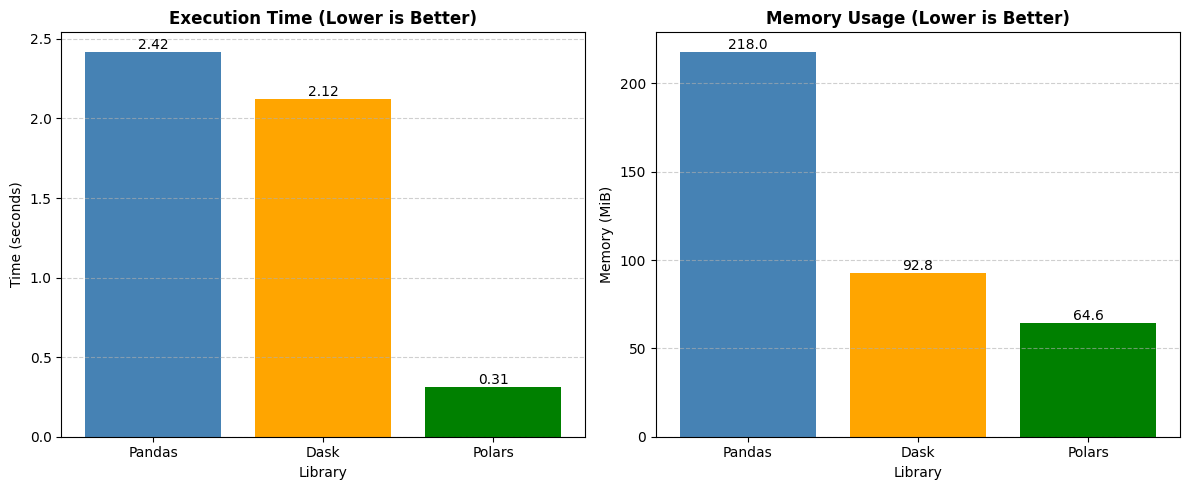

In [ ]:
import matplotlib.pyplot as plt

# Define consistent colors
color_map = {
    "Pandas": "steelblue",
    "Dask": "orange",
    "Polars": "green"
}

colors = [color_map[lib] for lib in comparison["Library"]]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ---------- Execution Time ----------
bars1 = axes[0].bar(
    comparison["Library"],
    comparison["Total Time (s)"],
    color=colors
)

axes[0].set_title("Execution Time (Lower is Better)", fontweight='bold')
axes[0].set_xlabel("Library")
axes[0].set_ylabel("Time (seconds)")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom')


# ---------- Memory Usage ----------
bars2 = axes[1].bar(
    comparison["Library"],
    comparison["Memory Usage (MiB)"],
    color=colors
)

axes[1].set_title("Memory Usage (Lower is Better)", fontweight='bold')
axes[1].set_xlabel("Library")
axes[1].set_ylabel("Memory (MiB)")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 📊 Performance Analysis

**Pandas Performance**  
Pandas showed moderate performance with an execution time of approximately **2.42 seconds**. As a single-threaded library, it processes data sequentially, resulting in slower execution and higher memory usage (~218 MiB) compared to scalable alternatives.

**Dask Performance**  
Dask demonstrated slightly better execution time (**2.12 seconds**) than Pandas in this experiment. It achieved lower memory usage (~93 MiB) due to its partitioning approach. However, it introduces overhead from task scheduling and coordination, which can limit performance gains in smaller environments such as Google Colab.

**Polars Performance**  
Polars demonstrated the best performance, with the fastest execution time (**0.31 seconds**) and the lowest memory usage (~65 MiB). This is due to its Rust-based architecture and built-in multi-threading, which efficiently utilises CPU cores and optimises execution.

**Scalability Consideration**  
Although Dask does not outperform Polars in this experiment, it is designed for distributed computing and is expected to perform better when handling much larger datasets across multiple machines or clusters.

**Overall Insight**  
These results highlight the trade-offs between performance, memory usage, and scalability. Polars provides the best speed and memory efficiency on a single machine, Pandas offers simplicity but higher resource usage, while Dask is more suitable for scalable, distributed data processing.